# EDA & Problem Understanding — Vietnamese Auto Parts Demand Forecasting

Notebook này dùng để:
- Hiểu bài toán dự báo `Quantity` theo ngày cho từng `ItemCode`.
- Kiểm tra chất lượng dữ liệu, dữ liệu âm, độ thưa của chuỗi SKU-ngày.
- Phân tích profit weight theo metric WRMSSE.
- Tạo validation nội bộ gần giống Kaggle.
- Tạo baseline đơn giản để có file submission đầu tiên.

> Ghi chú: Đây là notebook EDA + baseline, chưa phải notebook model cuối cùng.

## 0. Import thư viện và cấu hình đường dẫn

Bạn chỉ cần để `train.csv` và `sample_submission.csv` cùng thư mục với notebook.  
Nếu chạy trên Kaggle/Colab, sửa `DATA_DIR` cho đúng.

In [25]:
import os
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# =========================
# SỬA ĐƯỜNG DẪN Ở ĐÂY NẾU CẦN
# =========================
DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "train.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

# Nếu chạy trong môi trường hiện tại của ChatGPT:
if not TRAIN_PATH.exists() and Path("/Users/apple/HBAAC/train.csv").exists():
    TRAIN_PATH = Path("/mnt/data/train.csv")
if not SAMPLE_PATH.exists() and Path("/Users/apple/HBAAC/sample_submission.csv").exists():
    SAMPLE_PATH = Path("/mnt/data/sample_submission.csv")

print("TRAIN_PATH:", TRAIN_PATH)
print("SAMPLE_PATH:", SAMPLE_PATH, "| exists:", SAMPLE_PATH.exists())

TRAIN_PATH: train.csv
SAMPLE_PATH: sample_submission.csv | exists: True


## 1. Đọc dữ liệu

Lưu ý:
- `UnitPrice` và `Unit Cost` đang là string kiểu số Việt Nam, ví dụ `123559,1`.
- Cần đổi dấu phẩy `,` thành dấu chấm `.` rồi ép kiểu float.

In [2]:
df = pd.read_csv(TRAIN_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.tail())
display(df.dtypes)

Shape: (711980, 8)


/var/folders/h4/1myh9v5149vfd754lvvkttpw0000gn/T/ipykernel_7586/1685540211.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(TRAIN_PATH)


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount
0,2020-11-17,2000004,SKU-08063,12,242700,2184300,"123559,1",1482709
1,2020-11-17,2000003,SKU-09458,600,"131818,1818",79090909,110000,66000000
2,2020-11-18,2000007,SKU-08062,6,230000,940909,101000,606000
3,2020-11-18,2000006,SKU-09458,240,270000,44181818,110000,26400000
4,2020-11-18,2000005,SKU-09458,240,270000,44181818,110000,26400000


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount
711975,2025-09-05,1933614,SKU-11617,1,468000,468000,365924,365924
711976,2025-09-05,1933616,SKU-09360,1,470000,470000,"312747,5",312747
711977,2025-09-05,1933616,SKU-09433,2,960000,1920000,"768779,63",1537559
711978,2025-09-05,1933616,SKU-11885,2,150000,300000,"114074,07",228148
711979,2025-09-05,1933616,SKU-11835,1,1300000,1300000,1120000,1120000


Date           object
Stt            object
ItemCode       object
Quantity        int64
UnitPrice      object
SalesAmount     int64
Unit Cost      object
Cost Amount    object
dtype: object

In [4]:
def parse_vn_number(s):
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")
    
    x = (
        s.astype(str)
         .str.strip()
         .str.replace(" ", "", regex=False)
         .str.replace(".", "", regex=False)
         .str.replace(",", ".", regex=False)
         .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )
    return pd.to_numeric(x, errors="coerce")

df["Date"] = pd.to_datetime(df["Date"])

df = df.rename(columns={
    "Unit Cost": "UnitCost",
    "Cost Amount": "CostAmount"
})

for col in ["Quantity", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount"]:
    df[col] = parse_vn_number(df[col])

display(df[["Quantity", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount"]].isna().sum().to_frame("missing_after_parse"))

df["line_profit"] = df["SalesAmount"] - df["CostAmount"]
df["demand_qty"] = df["Quantity"].clip(lower=0)

df["is_negative_qty"] = df["Quantity"] < 0
df["is_positive_qty"] = df["Quantity"] > 0
df["is_zero_revenue"] = df["SalesAmount"] == 0
df["is_negative_revenue"] = df["SalesAmount"] < 0
df["is_negative_cost"] = df["CostAmount"] < 0

display(df.head())
display(df.dtypes)

,missing_after_parse
Quantity,0
UnitPrice,0
SalesAmount,0
UnitCost,0
CostAmount,0


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,UnitCost,CostAmount,line_profit,demand_qty,is_negative_qty,is_positive_qty,is_zero_revenue,is_negative_revenue,is_negative_cost
0,2020-11-17,2000004,SKU-08063,12,"242,700.0000",2184300,"123,559.1000","1,482,709.0000","701,591.0000",12,False,True,False,False,False
1,2020-11-17,2000003,SKU-09458,600,"131,818.1818",79090909,"110,000.0000","66,000,000.0000","13,090,909.0000",600,False,True,False,False,False
2,2020-11-18,2000007,SKU-08062,6,"230,000.0000",940909,"101,000.0000","606,000.0000","334,909.0000",6,False,True,False,False,False
3,2020-11-18,2000006,SKU-09458,240,"270,000.0000",44181818,"110,000.0000","26,400,000.0000","17,781,818.0000",240,False,True,False,False,False
4,2020-11-18,2000005,SKU-09458,240,"270,000.0000",44181818,"110,000.0000","26,400,000.0000","17,781,818.0000",240,False,True,False,False,False


Date                   datetime64[ns]
Stt                            object
ItemCode                       object
Quantity                        int64
UnitPrice                     float64
SalesAmount                     int64
UnitCost                      float64
CostAmount                    float64
line_profit                   float64
demand_qty                      int64
is_negative_qty                  bool
is_positive_qty                  bool
is_zero_revenue                  bool
is_negative_revenue              bool
is_negative_cost                 bool
dtype: object

## 2. Tổng quan dữ liệu

Kiểm tra:
- Số dòng, số SKU.
- Khoảng ngày.
- Missing value.
- Duplicate.
- Tổng quantity dương/âm.

In [5]:
overview = {
    "n_rows": len(df),
    "n_skus": df["ItemCode"].nunique(),
    "min_date": df["Date"].min(),
    "max_date": df["Date"].max(),
    "n_days": df["Date"].nunique(),
    "calendar_days": (df["Date"].max() - df["Date"].min()).days + 1,
    "total_quantity_net": df["Quantity"].sum(),
    "total_demand_qty_positive_only": df["demand_qty"].sum(),
    "total_negative_quantity": df.loc[df["Quantity"] < 0, "Quantity"].sum(),
    "n_negative_qty_rows": int((df["Quantity"] < 0).sum()),
    "n_positive_qty_rows": int((df["Quantity"] > 0).sum()),
}
display(pd.Series(overview).to_frame("value"))

print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))

print("Duplicate rows:", df.duplicated().sum())

,value
n_rows,711980
n_skus,15972
min_date,2020-11-17 00:00:00
max_date,2025-09-05 00:00:00
n_days,1411
calendar_days,1754
total_quantity_net,2447253
total_demand_qty_positive_only,2534091
total_negative_quantity,-86838
n_negative_qty_rows,37434


Missing values:


,missing_count
Date,0
Stt,0
ItemCode,0
Quantity,0
UnitPrice,0
SalesAmount,0
UnitCost,0
CostAmount,0
line_profit,0
demand_qty,0


Duplicate rows: 1473


In [6]:
# Thống kê nhanh các cột số
num_cols = ["Quantity", "demand_qty", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount", "line_profit"]
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,50%,95%,99%,max
Quantity,"711,980.0000",3.4372,25.4907,-998.0000,-2.0000,-1.0000,1.0000,10.0000,30.0000,"5,998.0000"
demand_qty,"711,980.0000",3.5592,25.3052,0.0000,0.0000,0.0000,1.0000,10.0000,30.0000,"5,998.0000"
UnitPrice,"711,980.0000","536,172.6550","1,151,269.3757","-30,011,000.0000","-1,200,000.0000","-68,600.0000","285,000.0000","1,750,000.0000","3,450,000.0000","79,627,535.0000"
SalesAmount,"711,980.0000","970,936.6007","3,888,066.6254","-184,240,000.0000","-1,420,000.0000","-110,000.0000","510,000.0000","2,805,000.0000","7,968,000.0000","932,413,092.0000"
UnitCost,"711,980.0000","377,920.8296","665,555.0664","-19,799,019.3700","-893,717.6555","-40,000.0000","202,277.6000","1,334,680.0620","2,464,848.4007","40,500,000.0000"
CostAmount,"711,980.0000","733,517.4804","3,282,585.7400","-166,865,193.0000","-1,100,000.0000","-65,287.5500","366,139.0000","2,187,666.0000","6,057,758.4100","838,717,832.0000"
line_profit,"711,980.0000","237,419.1203","1,181,891.7277","-72,895,386.0000","-596,061.2400","-110,889.4500","125,972.0000","800,791.4500","2,005,899.0800","133,193,972.0000"


## 3. Phân tích `Quantity < 0`

BTC có nói: các dòng chỉ có `Quantity < 0` có thể là bảo hành, đổi miễn phí, hàng tặng kèm, chuyển kho nội bộ hoặc hao hụt.  
Vì vậy không nên hiểu tất cả dòng âm là “khách trả hàng” theo nghĩa demand âm.

Trong bài dự báo, target nên ưu tiên demand không âm:

```python
demand_qty = Quantity.clip(lower=0)
```

In [7]:
neg = df[df["Quantity"] < 0].copy()

print("Số dòng Quantity < 0:", len(neg))
display(
    neg[["Quantity", "SalesAmount", "CostAmount", "line_profit"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

neg_patterns = pd.DataFrame({
    "condition": [
        "Quantity < 0",
        "Quantity < 0 & SalesAmount < 0 & CostAmount < 0",
        "Quantity < 0 & SalesAmount == 0",
        "Quantity < 0 & SalesAmount < 0",
        "Quantity < 0 & CostAmount < 0",
        "Quantity < 0 & line_profit <= 0",
        "Quantity < 0 & line_profit > 0",
    ],
    "n_rows": [
        (df["Quantity"] < 0).sum(),
        ((df["Quantity"] < 0) & (df["SalesAmount"] < 0) & (df["CostAmount"] < 0)).sum(),
        ((df["Quantity"] < 0) & (df["SalesAmount"] == 0)).sum(),
        ((df["Quantity"] < 0) & (df["SalesAmount"] < 0)).sum(),
        ((df["Quantity"] < 0) & (df["CostAmount"] < 0)).sum(),
        ((df["Quantity"] < 0) & (df["line_profit"] <= 0)).sum(),
        ((df["Quantity"] < 0) & (df["line_profit"] > 0)).sum(),
    ]
})
display(neg_patterns)

Số dòng Quantity < 0: 37434


,count,mean,std,min,1%,5%,50%,95%,99%,max
Quantity,"37,434.0000",-2.3198,12.5557,-998.0000,-16.6700,-5.0000,-1.0000,-1.0000,-1.0000,-1.0000
SalesAmount,"37,434.0000","-977,429.1196","1,848,269.0574","-184,240,000.0000","-6,600,000.0000","-2,850,000.0000","-558,000.0000","-110,000.0000","-50,000.0000",0.0000
CostAmount,"37,434.0000","-749,316.4479","1,611,915.1047","-166,865,193.0000","-5,440,000.0000","-2,191,391.3500","-411,974.5000","-65,411.1500","-25,671.9100","1,190,000.0000"
line_profit,"37,434.0000","-228,112.6716","547,404.1526","-17,374,807.0000","-1,738,835.3700","-790,767.6000","-135,697.0000","-19,596.5000","425,601.8749","27,604,413.0000"


,condition,n_rows
0,Quantity < 0,37434
1,Quantity < 0 & SalesAmount < 0 & CostAmount < 0,37279
2,Quantity < 0 & SalesAmount == 0,119
3,Quantity < 0 & SalesAmount < 0,37315
4,Quantity < 0 & CostAmount < 0,37393
5,Quantity < 0 & line_profit <= 0,36137
6,Quantity < 0 & line_profit > 0,1297


In [8]:
# Top SKU có nhiều dòng âm nhất
neg_sku = (
    neg.groupby("ItemCode")
       .agg(
           neg_rows=("Quantity", "size"),
           neg_qty=("Quantity", "sum"),
           neg_sales=("SalesAmount", "sum"),
           neg_cost=("CostAmount", "sum"),
           neg_profit=("line_profit", "sum")
       )
       .sort_values("neg_rows", ascending=False)
)

display(neg_sku.head(20))

,neg_rows,neg_qty,neg_sales,neg_cost,neg_profit
ItemCode,,,,,
SKU-15599,97,-229,-32898820,"-23,499,154.5100","-9,399,665.4900"
SKU-15146,96,-184,-29871220,"-21,255,992.0800","-8,615,227.9200"
SKU-14323,94,-265,-65620464,"-50,066,803.5000","-15,553,660.5000"
SKU-00324,87,-90,-115109296,"-89,257,481.0000","-25,851,815.0000"
SKU-15145,86,-268,-32686755,"-22,890,808.6900","-9,795,946.3100"
SKU-14806,81,-148,-31896315,"-23,818,482.6000","-8,077,832.4000"
SKU-14320,78,-195,-46193432,"-33,167,697.5900","-13,025,734.4100"
SKU-09510,77,-377,-41492724,"-31,638,754.0900","-9,853,969.9100"
SKU-12064,77,-133,-128329222,"-65,156,458.1200","-63,172,763.8800"


## 4. Aggregate dữ liệu về mức SKU-ngày

Dữ liệu gốc là transaction line.  
Bài toán cần dự báo **daily demand per SKU**, nên cần gom:

```text
ItemCode + Date -> tổng demand_qty trong ngày
```

Ngày không xuất hiện trong giao dịch cần hiểu là demand = 0, không phải missing.

In [9]:
daily = (
    df.groupby(["ItemCode", "Date"], as_index=False)
      .agg(
          y=("demand_qty", "sum"),
          net_qty=("Quantity", "sum"),
          sales=("SalesAmount", "sum"),
          cost=("CostAmount", "sum"),
          profit=("line_profit", "sum"),
          n_lines=("Stt", "size")
      )
)

daily["is_positive_day"] = daily["y"] > 0

print("Daily sparse shape:", daily.shape)
display(daily.head())

n_skus = df["ItemCode"].nunique()
all_dates = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
n_calendar_days = len(all_dates)
possible_sku_days = n_skus * n_calendar_days
observed_sku_days = daily[["ItemCode", "Date"]].drop_duplicates().shape[0]
positive_sku_days = daily.loc[daily["y"] > 0, ["ItemCode", "Date"]].drop_duplicates().shape[0]

density_info = {
    "n_skus": n_skus,
    "n_calendar_days": n_calendar_days,
    "possible_sku_days": possible_sku_days,
    "observed_sku_days_in_transactions": observed_sku_days,
    "positive_sku_days": positive_sku_days,
    "positive_density": positive_sku_days / possible_sku_days,
}
display(pd.Series(density_info).to_frame("value"))

Daily sparse shape: (507050, 9)


,ItemCode,Date,y,net_qty,sales,cost,profit,n_lines,is_positive_day
0,SKU-00001,2025-05-26,1,1,830368,0.0000,"830,368.0000",1,True
1,SKU-00001,2025-05-27,1,1,1032840,0.0000,"1,032,840.0000",1,True
2,SKU-00001,2025-05-28,2,2,2084484,0.0000,"2,084,484.0000",2,True
3,SKU-00001,2025-05-30,2,2,1414600,0.0000,"1,414,600.0000",2,True
4,SKU-00001,2025-06-04,6,6,4138320,0.0000,"4,138,320.0000",6,True


,value
n_skus,"15,972.0000"
n_calendar_days,"1,754.0000"
possible_sku_days,"28,014,888.0000"
observed_sku_days_in_transactions,"507,050.0000"
positive_sku_days,"485,454.0000"
positive_density,0.0173


## 5. Phân tích theo thời gian toàn hệ thống

Mục tiêu:
- Xem tổng demand theo ngày.
- Xem có xu hướng tăng/giảm không.
- Xem weekday effect, đặc biệt Chủ nhật.

In [10]:
daily_total = (
    daily.groupby("Date", as_index=False)
         .agg(
             total_y=("y", "sum"),
             total_net_qty=("net_qty", "sum"),
             total_sales=("sales", "sum"),
             total_profit=("profit", "sum"),
             active_skus=("ItemCode", "nunique"),
             n_lines=("n_lines", "sum")
         )
)

# Fill đủ ngày lịch để thấy ngày không bán
daily_total = (
    pd.DataFrame({"Date": all_dates})
    .merge(daily_total, on="Date", how="left")
    .fillna({
        "total_y": 0,
        "total_net_qty": 0,
        "total_sales": 0,
        "total_profit": 0,
        "active_skus": 0,
        "n_lines": 0
    })
)

daily_total["dow"] = daily_total["Date"].dt.dayofweek
daily_total["day_name"] = daily_total["Date"].dt.day_name()
daily_total["month"] = daily_total["Date"].dt.month
daily_total["year"] = daily_total["Date"].dt.year
daily_total["y_7d_ma"] = daily_total["total_y"].rolling(7, min_periods=1).mean()
daily_total["y_28d_ma"] = daily_total["total_y"].rolling(28, min_periods=1).mean()

display(daily_total.head())
display(daily_total.tail())

,Date,total_y,total_net_qty,total_sales,total_profit,active_skus,n_lines,dow,day_name,month,year,y_7d_ma,y_28d_ma
0,2020-11-17,612.0000,612.0000,"81,275,209.0000","13,792,500.0000",2.0000,2.0000,1,Tuesday,11,2020,612.0000,612.0000
1,2020-11-18,486.0000,486.0000,"89,304,545.0000","35,898,545.0000",2.0000,3.0000,2,Wednesday,11,2020,549.0000,549.0000
2,2020-11-19,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3,Thursday,11,2020,366.0000,366.0000
3,2020-11-20,240.0000,240.0000,"44,181,818.0000","17,781,818.0000",1.0000,1.0000,4,Friday,11,2020,334.5000,334.5000
4,2020-11-21,58.0000,58.0000,"14,510,455.0000","5,456,455.0000",7.0000,7.0000,5,Saturday,11,2020,279.2000,279.2000


,Date,total_y,total_net_qty,total_sales,total_profit,active_skus,n_lines,dow,day_name,month,year,y_7d_ma,y_28d_ma
1749,2025-09-01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,Monday,9,2025,"1,135.1429","1,298.1071"
1750,2025-09-02,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,Tuesday,9,2025,"1,007.8571","1,261.8214"
1751,2025-09-03,"1,450.0000","1,405.0000","463,790,691.0000","110,179,683.8700",414.0000,580.0000,2,Wednesday,9,2025,"1,074.1429","1,264.1786"
1752,2025-09-04,"2,818.0000","2,784.0000","692,243,687.0000","115,881,863.3700",387.0000,518.0000,3,Thursday,9,2025,942.1429,"1,329.4286"
1753,2025-09-05,"1,391.0000","1,323.0000","419,348,229.0000","81,462,571.5700",421.0000,545.0000,4,Friday,9,2025,"1,015.8571","1,333.5000"


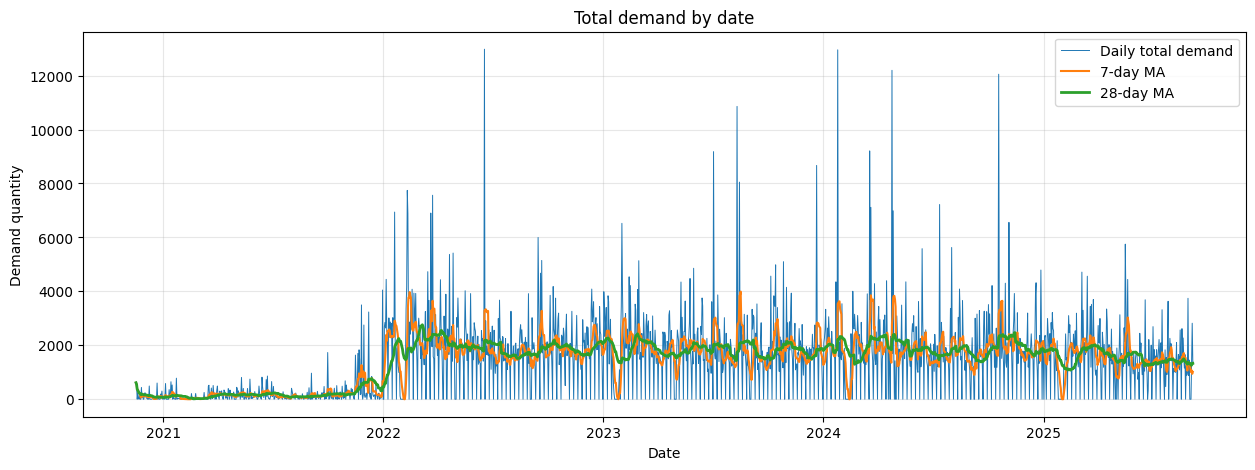

In [11]:
plt.figure(figsize=(15, 5))
plt.plot(daily_total["Date"], daily_total["total_y"], linewidth=0.7, label="Daily total demand")
plt.plot(daily_total["Date"], daily_total["y_7d_ma"], linewidth=1.5, label="7-day MA")
plt.plot(daily_total["Date"], daily_total["y_28d_ma"], linewidth=2, label="28-day MA")
plt.title("Total demand by date")
plt.xlabel("Date")
plt.ylabel("Demand quantity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

,mean_y,median_y,max_y,mean_active_skus,n_days
day_name,,,,,
Monday,"1,816.7120","1,866.5000","9,208.0000",371.3600,250
Tuesday,"1,688.1713","1,727.0000","8,050.0000",351.5139,251
Wednesday,"1,769.3785","1,686.0000","12,196.0000",338.1195,251
Thursday,"1,777.8406","1,698.0000","12,956.0000",330.6972,251
Friday,"1,764.9442","1,660.0000","12,051.0000",331.1713,251
Saturday,"1,289.0360","1,395.5000","12,979.0000",299.8600,250
Sunday,2.2800,0.0000,506.0000,0.0720,250


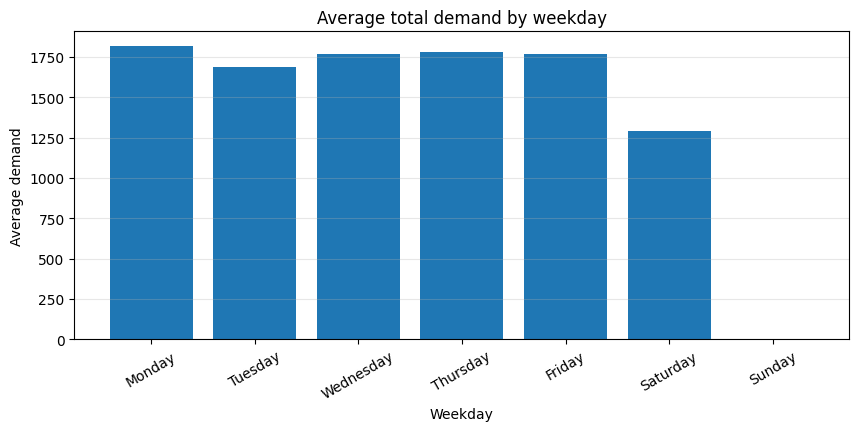

In [12]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_stats = (
    daily_total.groupby("day_name")
    .agg(
        mean_y=("total_y", "mean"),
        median_y=("total_y", "median"),
        max_y=("total_y", "max"),
        mean_active_skus=("active_skus", "mean"),
        n_days=("Date", "size")
    )
    .reindex(weekday_order)
)

display(weekday_stats)

plt.figure(figsize=(10, 4))
plt.bar(weekday_stats.index, weekday_stats["mean_y"])
plt.title("Average total demand by weekday")
plt.xlabel("Weekday")
plt.ylabel("Average demand")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

,year,month,total_y,mean_daily_y,mean_active_skus,total_profit,year_month
44,2024,7,"53,475.0000","1,725.0000",366.4516,"2,486,670,098.7900",2024-07-01
45,2024,8,"57,820.0000","1,865.1613",385.7097,"3,031,708,033.9800",2024-08-01
46,2024,9,"45,894.0000","1,529.8000",327.8667,"2,800,765,896.6100",2024-09-01
47,2024,10,"71,795.0000","2,315.9677",366.9032,"3,711,281,091.6600",2024-10-01
48,2024,11,"59,482.0000","1,982.7333",396.6667,"3,569,364,193.8500",2024-11-01
49,2024,12,"56,149.0000","1,811.2581",411.7742,"3,807,281,047.3600",2024-12-01
50,2025,1,"40,470.0000","1,305.4839",292.4516,"2,516,364,758.6300",2025-01-01
51,2025,2,"45,508.0000","1,625.2857",341.1071,"2,974,271,415.6500",2025-02-01
52,2025,3,"58,578.0000","1,889.6129",352.8387,"3,518,918,050.5800",2025-03-01
53,2025,4,"46,860.0000","1,562.0000",337.1333,"2,843,986,453.7500",2025-04-01


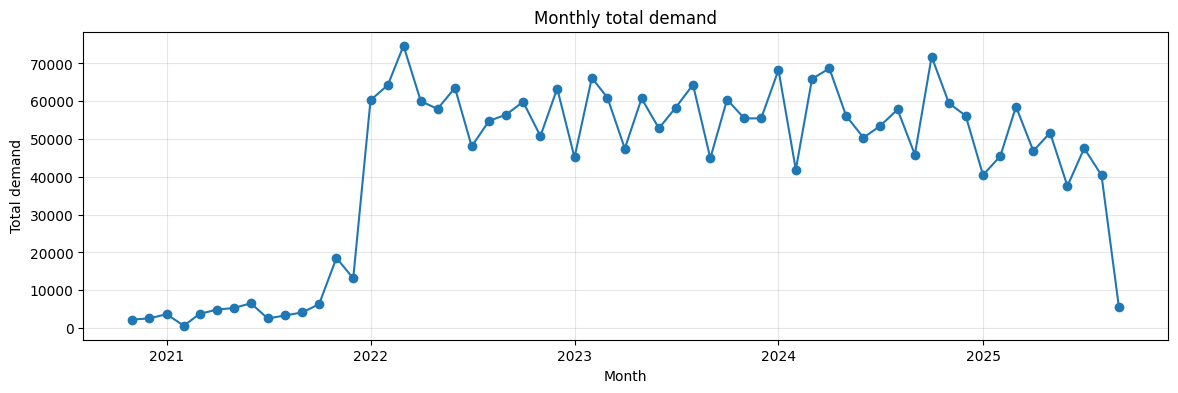

In [13]:
monthly_stats = (
    daily_total.groupby(["year", "month"], as_index=False)
    .agg(
        total_y=("total_y", "sum"),
        mean_daily_y=("total_y", "mean"),
        mean_active_skus=("active_skus", "mean"),
        total_profit=("total_profit", "sum")
    )
)

monthly_stats["year_month"] = pd.to_datetime(
    monthly_stats["year"].astype(str) + "-" + monthly_stats["month"].astype(str) + "-01"
)

display(monthly_stats.tail(15))

plt.figure(figsize=(14, 4))
plt.plot(monthly_stats["year_month"], monthly_stats["total_y"], marker="o")
plt.title("Monthly total demand")
plt.xlabel("Month")
plt.ylabel("Total demand")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Phân tích SKU-level

Vì dữ liệu long-tail, cần biết:
- SKU nào bán nhiều.
- SKU nào gần như không bán.
- SKU nào có profit cao, ảnh hưởng mạnh đến điểm.
- SKU nào profit ≤ 0, weight = 0 trong WRMSSE.

In [14]:
# SKU summary từ daily demand
sku_daily_summary = (
    daily.groupby("ItemCode")
    .agg(
        total_y=("y", "sum"),
        total_net_qty=("net_qty", "sum"),
        positive_days=("is_positive_day", "sum"),
        observed_days=("Date", "nunique"),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        total_sales=("sales", "sum"),
        total_cost=("cost", "sum"),
        total_profit_from_daily=("profit", "sum"),
        total_lines=("n_lines", "sum")
    )
    .reset_index()
)

# Profit theo đúng metric từ transaction-level
sku_profit = (
    df.groupby("ItemCode", as_index=False)
      .agg(metric_profit=("line_profit", "sum"))
)

sku_summary = sku_daily_summary.merge(sku_profit, on="ItemCode", how="left")

sku_summary["metric_profit_pos"] = sku_summary["metric_profit"].clip(lower=0)
total_positive_profit = sku_summary["metric_profit_pos"].sum()
sku_summary["weight"] = np.where(
    total_positive_profit > 0,
    sku_summary["metric_profit_pos"] / total_positive_profit,
    0
)

sku_summary["active_span_days"] = (sku_summary["last_date"] - sku_summary["first_date"]).dt.days + 1
sku_summary["avg_y_per_calendar_day"] = sku_summary["total_y"] / n_calendar_days
sku_summary["avg_y_when_sold"] = sku_summary["total_y"] / sku_summary["positive_days"].replace(0, np.nan)
sku_summary["days_since_last_activity"] = (df["Date"].max() - sku_summary["last_date"]).dt.days

sku_summary = sku_summary.sort_values("weight", ascending=False)

display(sku_summary.head(20))
display(sku_summary.describe(percentiles=[0.01, 0.05, 0.5, 0.9, 0.95, 0.99]).T)

,ItemCode,total_y,total_net_qty,positive_days,observed_days,first_date,last_date,total_sales,total_cost,total_profit_from_daily,total_lines,metric_profit,metric_profit_pos,weight,active_span_days,avg_y_per_calendar_day,avg_y_when_sold,days_since_last_activity
2,SKU-00003,10935,10935,1061,1061,2022-01-03,2025-09-04,16700681088,0.0000,"16,700,681,088.0000",10936,"16,700,681,088.0000","16,700,681,088.0000",0.0970,1341,6.2343,10.3063,1
1,SKU-00002,5894,5894,895,895,2022-01-10,2025-09-05,8012686409,0.0000,"8,012,686,409.0000",5896,"8,012,686,409.0000","8,012,686,409.0000",0.0465,1335,3.3603,6.5855,0
9197,SKU-09458,62430,62427,82,84,2020-11-17,2024-04-24,10081348060,"7,440,227,164.5100","2,641,120,895.4900",154,"2,641,120,895.4900","2,641,120,895.4900",0.0153,1255,35.5929,761.3415,499
4,SKU-00005,1101,1101,327,327,2022-01-03,2023-06-26,2243340437,0.0000,"2,243,340,437.0000",1103,"2,243,340,437.0000","2,243,340,437.0000",0.0130,540,0.6277,3.3670,802
8354,SKU-08589,29011,29011,53,54,2021-05-11,2025-05-15,4882727643,"3,597,022,282.4900","1,285,705,360.5100",106,"1,285,705,360.5100","1,285,705,360.5100",0.0075,1466,16.5399,547.3774,113
12229,SKU-12534,28486,28349,657,661,2021-03-17,2025-09-04,5356791254,"4,140,987,461.0000","1,215,803,793.0000",1556,"1,215,803,793.0000","1,215,803,793.0000",0.0071,1633,16.2406,43.3577,1
9492,SKU-09760,222295,220421,994,996,2022-01-03,2025-09-05,5971433907,"4,776,120,850.0000","1,195,313,057.0000",3843,"1,195,313,057.0000","1,195,313,057.0000",0.0069,1342,126.7360,223.6368,0
12230,SKU-12537,24127,24036,676,679,2021-03-17,2025-08-12,4576081190,"3,469,281,397.0000","1,106,799,793.0000",1624,"1,106,799,793.0000","1,106,799,793.0000",0.0064,1610,13.7554,35.6908,24
315,SKU-00324,4800,4710,731,737,2022-01-03,2025-02-13,5669204524,"4,690,829,807.8300","978,374,716.1700",2488,"978,374,716.1700","978,374,716.1700",0.0057,1138,2.7366,6.5663,204
13993,SKU-14323,18183,17918,846,850,2022-01-03,2025-09-05,4229909138,"3,292,805,098.1900","937,104,039.8100",3536,"937,104,039.8100","937,104,039.8100",0.0054,1342,10.3666,21.4929,0


,count,mean,min,1%,5%,50%,90%,95%,99%,max,std
total_y,"15,972.0000",158.6583,0.0000,1.0000,1.0000,10.0000,182.0000,449.8000,"2,551.3400","222,295.0000","2,123.6163"
total_net_qty,"15,972.0000",153.2215,-4.0000,0.0000,1.0000,8.0000,170.0000,424.0000,"2,493.7700","220,421.0000","2,096.7145"
positive_days,"15,972.0000",30.3941,0.0000,1.0000,1.0000,6.0000,74.0000,143.0000,407.0000,"1,061.0000",76.5033
observed_days,"15,972.0000",31.7462,1.0000,1.0000,1.0000,6.0000,77.9000,150.0000,418.2900,"1,061.0000",78.2526
first_date,15972,2023-04-06 15:20:57.700976384,2020-11-17 00:00:00,2021-07-03 00:00:00,2022-01-03 00:00:00,2022-10-18 00:00:00,2025-02-21 00:00:00,2025-05-09 00:00:00,2025-08-12 00:00:00,2025-09-05 00:00:00,NaN
last_date,15972,2024-09-27 01:16:05.589782272,2020-12-31 00:00:00,2022-02-18 00:00:00,2022-08-11 00:00:00,2025-02-14 00:00:00,2025-08-26 00:00:00,2025-09-03 00:00:00,2025-09-05 00:00:00,2025-09-05 00:00:00,NaN
total_sales,"15,972.0000","43,281,207.1747","-1,256,000.0000",0.0000,"80,000.0000","4,519,283.0000","67,873,984.0000","154,866,435.8000","687,702,708.5500","16,700,681,088.0000","263,423,457.6548"
total_cost,"15,972.0000","32,697,832.1890","-1,473,077.0000",0.0000,"91,332.1500","3,534,961.4950","51,696,175.9300","117,655,928.9830","530,439,303.8367","8,564,915,422.1200","176,734,166.8990"
total_profit_from_daily,"15,972.0000","10,583,374.9857","-302,803,694.0000","-3,331,820.5200","-333,897.0500","954,000.0000","16,017,603.3000","35,311,495.5640","148,419,578.2119","16,700,681,088.0000","154,391,647.9245"
total_lines,"15,972.0000",44.5768,1.0000,1.0000,1.0000,7.0000,90.0000,187.0000,657.2900,"10,936.0000",175.9161


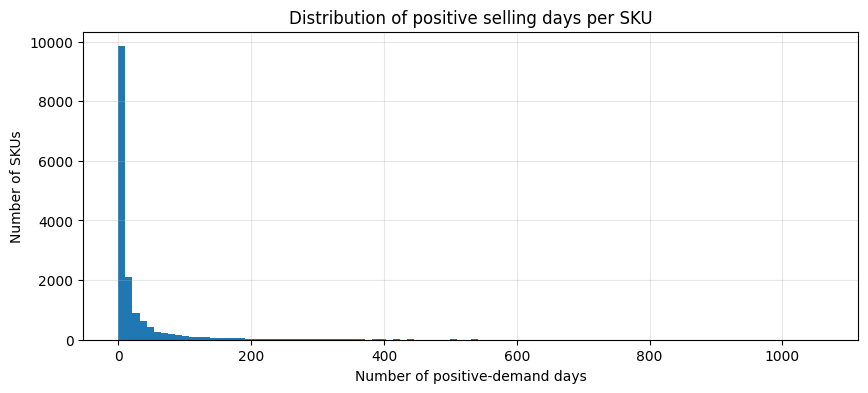

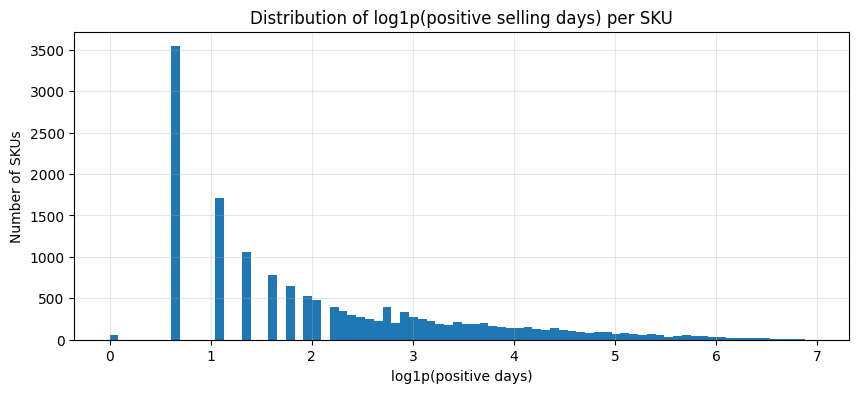

In [15]:
# Phân bố số ngày bán dương theo SKU
plt.figure(figsize=(10, 4))
plt.hist(sku_summary["positive_days"], bins=100)
plt.title("Distribution of positive selling days per SKU")
plt.xlabel("Number of positive-demand days")
plt.ylabel("Number of SKUs")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(np.log1p(sku_summary["positive_days"]), bins=80)
plt.title("Distribution of log1p(positive selling days) per SKU")
plt.xlabel("log1p(positive days)")
plt.ylabel("Number of SKUs")
plt.grid(True, alpha=0.3)
plt.show()

,positive_days_bucket,n_skus,total_y,total_profit,positive_profit,total_weight
0,0,58,0,"-184,039.7500",0.0000,0.0000
1,1,3541,10808,"354,731,590.3900","990,125,674.5900",0.0057
2,2-3,2767,14716,"1,034,416,826.5700","1,779,256,347.6200",0.0103
3,4-7,2434,29876,"3,201,864,442.9700","3,584,352,491.1900",0.0208
4,8-14,1983,61708,"5,331,009,191.8000","5,477,752,593.7100",0.0318
5,15-28,1847,112959,"9,088,213,212.6800","9,355,624,822.3800",0.0543
6,29-56,1334,192646,"12,278,946,244.3300","13,083,438,333.7300",0.0760
7,57-112,952,328257,"20,537,903,056.8100","20,621,082,073.5900",0.1198
8,113-365,852,732557,"47,113,322,748.9300","47,208,025,804.9300",0.2742
9,>365,204,1050564,"70,097,441,997.3600","70,097,441,997.3600",0.4071


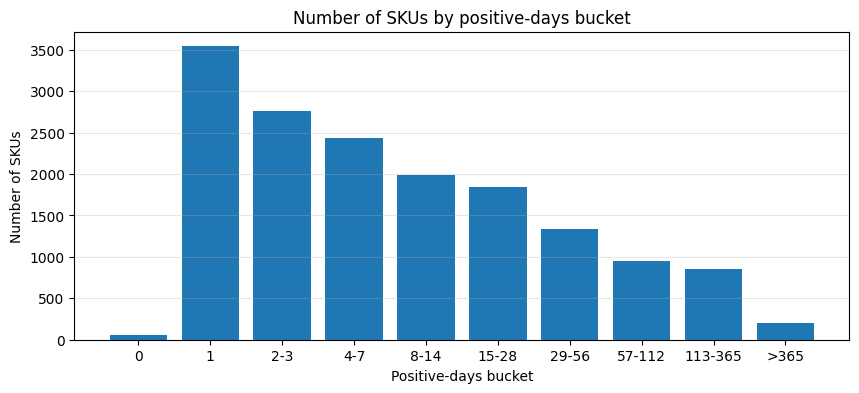

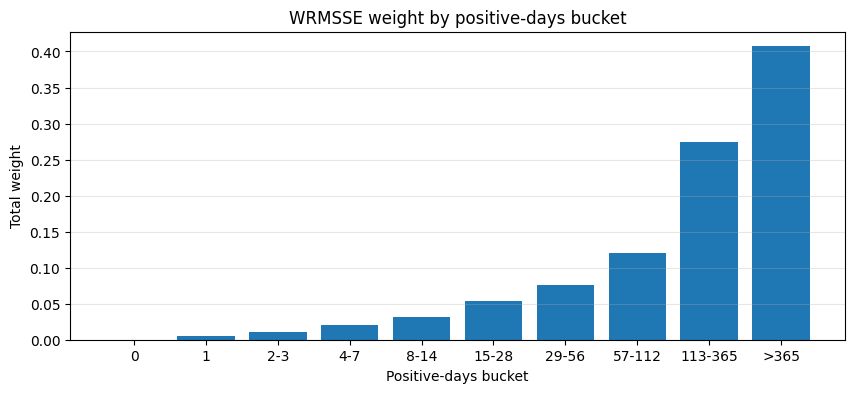

In [16]:
# Chia nhóm SKU theo độ thưa
bins = [-1, 0, 1, 3, 7, 14, 28, 56, 112, 365, np.inf]
labels = ["0", "1", "2-3", "4-7", "8-14", "15-28", "29-56", "57-112", "113-365", ">365"]

sku_summary["positive_days_bucket"] = pd.cut(
    sku_summary["positive_days"],
    bins=bins,
    labels=labels
)

bucket_stats = (
    sku_summary.groupby("positive_days_bucket", observed=True)
    .agg(
        n_skus=("ItemCode", "size"),
        total_y=("total_y", "sum"),
        total_profit=("metric_profit", "sum"),
        positive_profit=("metric_profit_pos", "sum"),
        total_weight=("weight", "sum")
    )
    .reset_index()
)

display(bucket_stats)

plt.figure(figsize=(10, 4))
plt.bar(bucket_stats["positive_days_bucket"].astype(str), bucket_stats["n_skus"])
plt.title("Number of SKUs by positive-days bucket")
plt.xlabel("Positive-days bucket")
plt.ylabel("Number of SKUs")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(bucket_stats["positive_days_bucket"].astype(str), bucket_stats["total_weight"])
plt.title("WRMSSE weight by positive-days bucket")
plt.xlabel("Positive-days bucket")
plt.ylabel("Total weight")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 7. Profit weight và long-tail effect

WRMSSE tính weighted average theo profit:

```text
profit_i = sum(SalesAmount - CostAmount)
profit_i <= 0 => weight_i = 0
```

Vì vậy SKU profit cao ảnh hưởng điểm nhiều hơn rất nhiều.

,top_k,cum_weight
0,10,0.2109
1,50,0.3225
2,100,0.3982
3,200,0.4908
4,500,0.6338
5,1000,0.7473
6,2000,0.8518
7,5000,0.9575
8,15972,1.0000


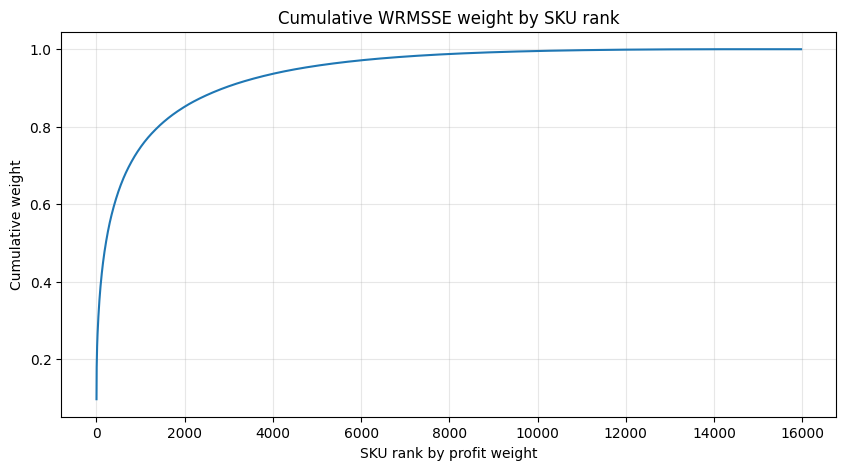

,rank,ItemCode,weight,cum_weight,metric_profit,total_y,positive_days,avg_y_per_calendar_day,days_since_last_activity
0,1,SKU-00003,0.0970,0.0970,"16,700,681,088.0000",10935,1061,6.2343,1
1,2,SKU-00002,0.0465,0.1435,"8,012,686,409.0000",5894,895,3.3603,0
2,3,SKU-09458,0.0153,0.1589,"2,641,120,895.4900",62430,82,35.5929,499
3,4,SKU-00005,0.0130,0.1719,"2,243,340,437.0000",1101,327,0.6277,802
4,5,SKU-08589,0.0075,0.1793,"1,285,705,360.5100",29011,53,16.5399,113
5,6,SKU-12534,0.0071,0.1864,"1,215,803,793.0000",28486,657,16.2406,1
6,7,SKU-09760,0.0069,0.1934,"1,195,313,057.0000",222295,994,126.7360,0
7,8,SKU-12537,0.0064,0.1998,"1,106,799,793.0000",24127,676,13.7554,24
8,9,SKU-00324,0.0057,0.2055,"978,374,716.1700",4800,731,2.7366,204
9,10,SKU-14323,0.0054,0.2109,"937,104,039.8100",18183,846,10.3666,0


In [17]:
weight_sorted = sku_summary.sort_values("weight", ascending=False).reset_index(drop=True)
weight_sorted["cum_weight"] = weight_sorted["weight"].cumsum()
weight_sorted["rank"] = np.arange(1, len(weight_sorted) + 1)

top_ks = [10, 50, 100, 200, 500, 1000, 2000, 5000, len(weight_sorted)]
top_weight_table = []
for k in top_ks:
    top_weight_table.append({
        "top_k": k,
        "cum_weight": weight_sorted.loc[:k-1, "weight"].sum()
    })
top_weight_table = pd.DataFrame(top_weight_table)

display(top_weight_table)

plt.figure(figsize=(10, 5))
plt.plot(weight_sorted["rank"], weight_sorted["cum_weight"])
plt.title("Cumulative WRMSSE weight by SKU rank")
plt.xlabel("SKU rank by profit weight")
plt.ylabel("Cumulative weight")
plt.grid(True, alpha=0.3)
plt.show()

display(weight_sorted.head(30)[[
    "rank", "ItemCode", "weight", "cum_weight", "metric_profit",
    "total_y", "positive_days", "avg_y_per_calendar_day", "days_since_last_activity"
]])

In [18]:
profit_status = pd.DataFrame({
    "group": ["profit > 0", "profit = 0", "profit < 0"],
    "n_skus": [
        (sku_summary["metric_profit"] > 0).sum(),
        (sku_summary["metric_profit"] == 0).sum(),
        (sku_summary["metric_profit"] < 0).sum()
    ],
    "total_y": [
        sku_summary.loc[sku_summary["metric_profit"] > 0, "total_y"].sum(),
        sku_summary.loc[sku_summary["metric_profit"] == 0, "total_y"].sum(),
        sku_summary.loc[sku_summary["metric_profit"] < 0, "total_y"].sum()
    ],
    "total_weight": [
        sku_summary.loc[sku_summary["metric_profit"] > 0, "weight"].sum(),
        sku_summary.loc[sku_summary["metric_profit"] == 0, "weight"].sum(),
        sku_summary.loc[sku_summary["metric_profit"] < 0, "weight"].sum()
    ]
})
display(profit_status)

,group,n_skus,total_y,total_weight
0,profit > 0,14156,2465009,1.0000
1,profit = 0,528,3301,0.0000
2,profit < 0,1288,65781,0.0000


## 8. Xem kỹ một vài SKU quan trọng

Các SKU top weight nên được xem riêng để hiểu pattern.

In [19]:
def plot_sku_series(item_code, start_date=None, end_date=None):
    """
    Vẽ chuỗi daily demand của một SKU, có fill ngày thiếu = 0.
    """
    tmp = daily.loc[daily["ItemCode"] == item_code, ["Date", "y"]].copy()
    all_d = pd.DataFrame({"Date": all_dates})
    tmp = all_d.merge(tmp, on="Date", how="left").fillna({"y": 0})

    if start_date is not None:
        tmp = tmp[tmp["Date"] >= pd.to_datetime(start_date)]
    if end_date is not None:
        tmp = tmp[tmp["Date"] <= pd.to_datetime(end_date)]

    tmp["y_28d_ma"] = tmp["y"].rolling(28, min_periods=1).mean()

    plt.figure(figsize=(15, 4))
    plt.plot(tmp["Date"], tmp["y"], linewidth=0.8, label="daily y")
    plt.plot(tmp["Date"], tmp["y_28d_ma"], linewidth=2, label="28-day MA")
    plt.title(f"Daily demand for {item_code}")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

top_items = weight_sorted["ItemCode"].head(5).tolist()
top_items

['SKU-00003', 'SKU-00002', 'SKU-09458', 'SKU-00005', 'SKU-08589']

,ItemCode,weight,metric_profit,total_y,positive_days,avg_y_per_calendar_day,avg_y_when_sold,days_since_last_activity
2,SKU-00003,0.0970,"16,700,681,088.0000",10935,1061,6.2343,10.3063,1


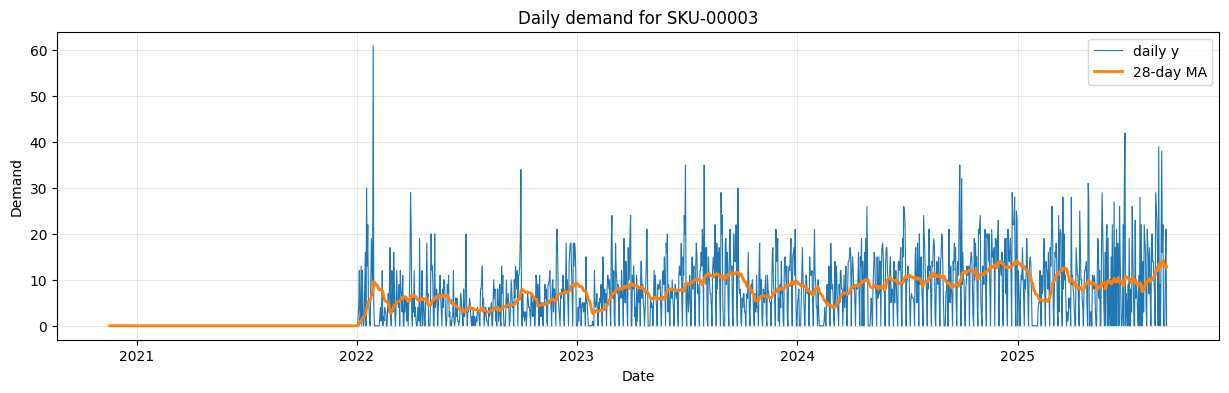

,ItemCode,weight,metric_profit,total_y,positive_days,avg_y_per_calendar_day,avg_y_when_sold,days_since_last_activity
1,SKU-00002,0.0465,"8,012,686,409.0000",5894,895,3.3603,6.5855,0


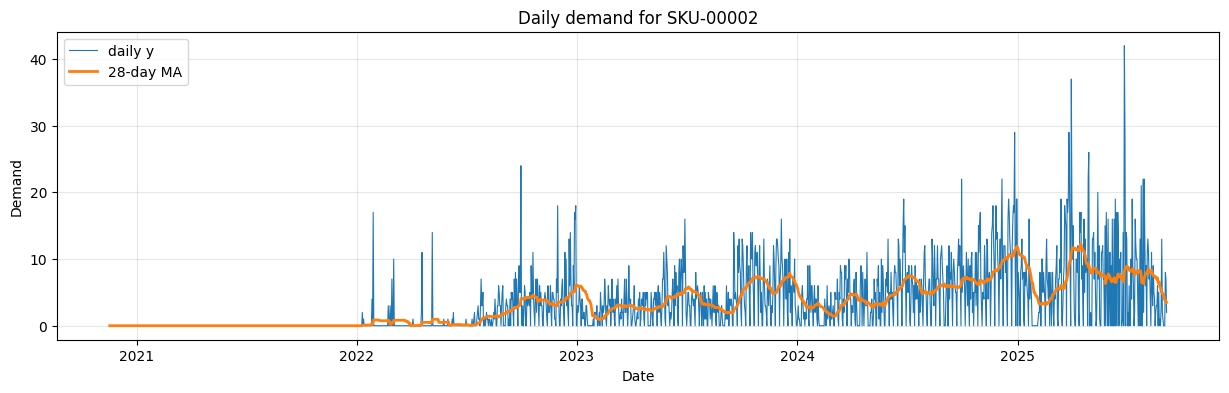

,ItemCode,weight,metric_profit,total_y,positive_days,avg_y_per_calendar_day,avg_y_when_sold,days_since_last_activity
9197,SKU-09458,0.0153,"2,641,120,895.4900",62430,82,35.5929,761.3415,499


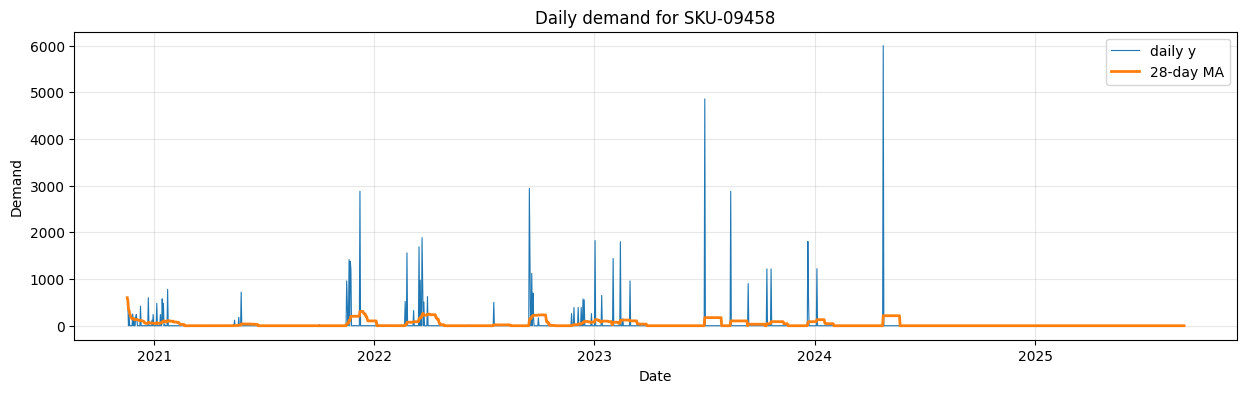

,ItemCode,weight,metric_profit,total_y,positive_days,avg_y_per_calendar_day,avg_y_when_sold,days_since_last_activity
4,SKU-00005,0.0130,"2,243,340,437.0000",1101,327,0.6277,3.3670,802


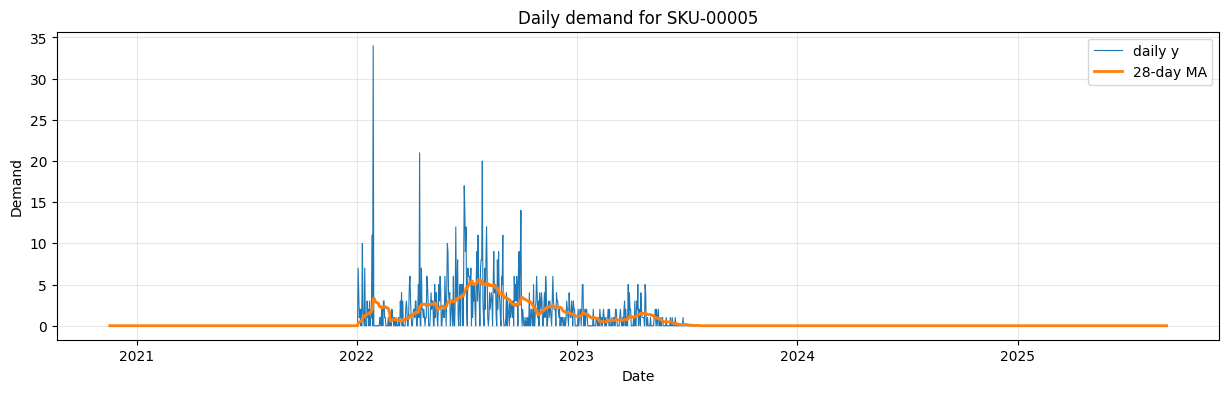

,ItemCode,weight,metric_profit,total_y,positive_days,avg_y_per_calendar_day,avg_y_when_sold,days_since_last_activity
8354,SKU-08589,0.0075,"1,285,705,360.5100",29011,53,16.5399,547.3774,113


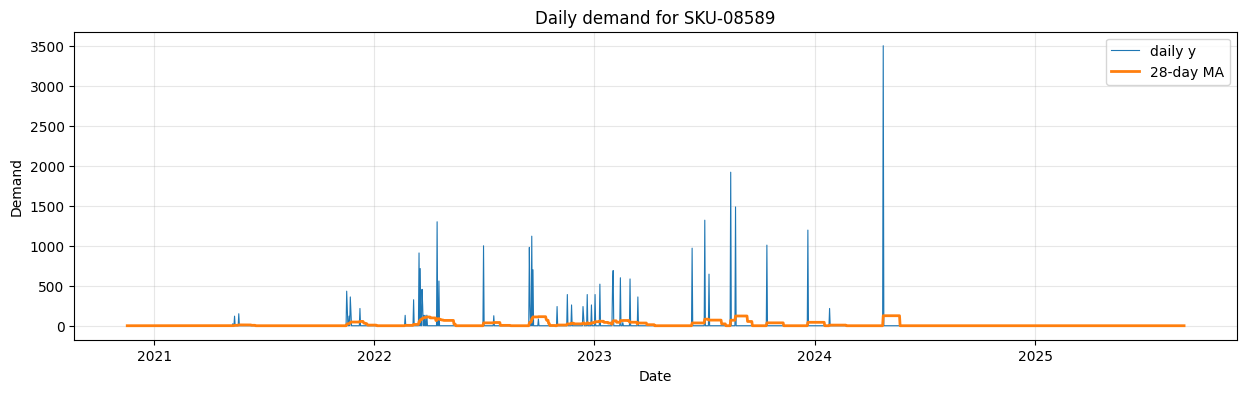

In [20]:
for item in top_items:
    info = sku_summary.loc[sku_summary["ItemCode"] == item, [
        "ItemCode", "weight", "metric_profit", "total_y", "positive_days",
        "avg_y_per_calendar_day", "avg_y_when_sold", "days_since_last_activity"
    ]]
    display(info)
    plot_sku_series(item)

## 9. Tạo hàm tính WRMSSE nội bộ

Ý tưởng:
1. Tính scale của từng SKU từ chuỗi train:
   ```text
   scale_i = mean((y_t - y_{t-1})^2)
   ```
2. Với horizon `h`, tính MSE dự báo của từng SKU.
3. RMSSE từng SKU:
   ```text
   sqrt(MSE_i / scale_i)
   ```
4. Weighted average theo profit weight.

Ghi chú:
- Nếu scale = 0, cần dùng epsilon nhỏ để tránh chia 0.
- Khi validation nội bộ, nên fill các ngày không bán = 0.

In [21]:
EPS = 1e-9

def compute_sku_weights(transactions):
    """
    Tính profit weight theo mô tả metric.
    """
    tmp = transactions.copy()
    if "line_profit" not in tmp.columns:
        tmp["line_profit"] = tmp["SalesAmount"] - tmp["CostAmount"]

    w = (
        tmp.groupby("ItemCode")["line_profit"]
           .sum()
           .clip(lower=0)
           .rename("profit_pos")
           .reset_index()
    )

    total = w["profit_pos"].sum()
    w["weight"] = np.where(total > 0, w["profit_pos"] / total, 0)
    return w[["ItemCode", "weight", "profit_pos"]]


def aggregate_daily_y(transactions, value_col="demand_qty"):
    """
    Aggregate transaction-level -> daily SKU-level.
    Chỉ trả về sparse daily, ngày không có giao dịch chưa được fill.
    """
    return (
        transactions.groupby(["ItemCode", "Date"], as_index=False)[value_col]
        .sum()
        .rename(columns={value_col: "y"})
    )


def compute_rmsse_scale(train_daily_sparse, sku_list, train_dates):
    """
    Tính scale cho từng SKU, có fill ngày thiếu = 0.
    Cách loop này tránh tạo full matrix quá lớn trong RAM.
    """
    date_to_idx = pd.Series(np.arange(len(train_dates)), index=train_dates)

    result = []
    grouped = dict(tuple(train_daily_sparse.groupby("ItemCode")))

    for sku in sku_list:
        arr = np.zeros(len(train_dates), dtype=np.float32)

        if sku in grouped:
            g = grouped[sku]
            idx = date_to_idx.loc[g["Date"]].to_numpy()
            arr[idx] = g["y"].to_numpy(dtype=np.float32)

        if len(arr) <= 1:
            scale = EPS
        else:
            diffs = np.diff(arr)
            scale = float(np.mean(diffs ** 2))
            if scale <= 0:
                scale = EPS

        result.append((sku, scale))

    return pd.DataFrame(result, columns=["ItemCode", "scale"])


def make_actual_matrix_long(daily_sparse, sku_list, dates, value_col="y"):
    """
    Tạo long dataframe đầy đủ SKU x dates với actual y.
    Dùng cho validation horizon, vì horizon chỉ 28/56 ngày nên RAM ổn.
    """
    idx = pd.MultiIndex.from_product([sku_list, dates], names=["ItemCode", "Date"])
    s = daily_sparse.set_index(["ItemCode", "Date"])[value_col]
    out = s.reindex(idx, fill_value=0).reset_index()
    out = out.rename(columns={value_col: "actual"})
    return out


def wrmsse_score(actual_long, pred_long, scale_df, weight_df):
    """
    actual_long: ItemCode, Date, actual
    pred_long:   ItemCode, Date, pred
    scale_df:    ItemCode, scale
    weight_df:   ItemCode, weight
    """
    eval_df = (
        actual_long.merge(pred_long, on=["ItemCode", "Date"], how="left")
                   .merge(scale_df, on="ItemCode", how="left")
                   .merge(weight_df[["ItemCode", "weight"]], on="ItemCode", how="left")
    )

    eval_df["pred"] = eval_df["pred"].fillna(0).clip(lower=0)
    eval_df["actual"] = eval_df["actual"].fillna(0)
    eval_df["scale"] = eval_df["scale"].fillna(EPS).clip(lower=EPS)
    eval_df["weight"] = eval_df["weight"].fillna(0)
    eval_df["se"] = (eval_df["actual"] - eval_df["pred"]) ** 2

    sku_eval = (
        eval_df.groupby("ItemCode")
        .agg(
            mse=("se", "mean"),
            scale=("scale", "first"),
            weight=("weight", "first")
        )
        .reset_index()
    )

    sku_eval["rmsse"] = np.sqrt(sku_eval["mse"] / sku_eval["scale"])
    score = float((sku_eval["rmsse"] * sku_eval["weight"]).sum())

    return score, sku_eval, eval_df

## 10. Validation split nội bộ

Vì cần dự báo 56 ngày sau train, ta giả lập:
- Train nội bộ: từ đầu đến trước 56 ngày cuối.
- Validation nội bộ: 56 ngày cuối của train.

Có thể thay `H = 28` nếu muốn test riêng public window.

In [22]:
H = 56

max_date = df["Date"].max()
valid_start = max_date - pd.Timedelta(days=H-1)
valid_end = max_date

print("Validation start:", valid_start)
print("Validation end:", valid_end)

train_part = df[df["Date"] < valid_start].copy()
valid_part = df[(df["Date"] >= valid_start) & (df["Date"] <= valid_end)].copy()

print("train_part:", train_part["Date"].min(), "->", train_part["Date"].max(), train_part.shape)
print("valid_part:", valid_part["Date"].min(), "->", valid_part["Date"].max(), valid_part.shape)

sku_list = sorted(df["ItemCode"].unique())
train_dates = pd.date_range(train_part["Date"].min(), train_part["Date"].max(), freq="D")
valid_dates = pd.date_range(valid_start, valid_end, freq="D")

train_daily_part = aggregate_daily_y(train_part)
valid_daily_part = aggregate_daily_y(valid_part)

weight_part = compute_sku_weights(train_part)
scale_part = compute_rmsse_scale(train_daily_part, sku_list, train_dates)
actual_valid_long = make_actual_matrix_long(valid_daily_part, sku_list, valid_dates)

display(weight_part.head())
display(scale_part.head())
display(actual_valid_long.head())

Validation start: 2025-07-12 00:00:00
Validation end: 2025-09-05 00:00:00
train_part: 2020-11-17 00:00:00 -> 2025-07-11 00:00:00 (689708, 15)
valid_part: 2025-07-12 00:00:00 -> 2025-09-05 00:00:00 (22272, 15)


,ItemCode,weight,profit_pos
0,SKU-00001,0.0002,"26,625,024.0000"
1,SKU-00002,0.0452,"7,556,426,552.0000"
2,SKU-00003,0.0951,"15,876,710,129.0000"
3,SKU-00004,0.0050,"835,996,756.0000"
4,SKU-00005,0.0134,"2,243,340,437.0000"


,ItemCode,scale
0,SKU-00001,0.0601
1,SKU-00002,22.8220
2,SKU-00003,56.2817
3,SKU-00004,1.1526
4,SKU-00005,4.5692


,ItemCode,Date,actual
0,SKU-00001,2025-07-12,0
1,SKU-00001,2025-07-13,0
2,SKU-00001,2025-07-14,0
3,SKU-00001,2025-07-15,0
4,SKU-00001,2025-07-16,0


## 11. Baseline đơn giản

Baseline này dùng:
- Trung bình demand trong 28/56/90/180 ngày gần nhất.
- Weekday factor học từ toàn hệ thống.
- Penalty cho SKU quá thưa hoặc lâu không bán.

Đây là baseline để submit thử, chưa phải model tối ưu.

In [23]:
def build_baseline_forecast(
    transactions,
    forecast_dates,
    sku_list,
    windows=(28, 56, 90, 180),
    window_weights=(0.35, 0.30, 0.20, 0.15),
    sparse_penalty=True
):
    """
    Tạo forecast long: ItemCode, Date, pred
    """
    assert len(windows) == len(window_weights)

    train_end = transactions["Date"].max()
    train_start = transactions["Date"].min()

    daily_sparse = aggregate_daily_y(transactions)

    # SKU stats
    sku_stats = (
        daily_sparse.groupby("ItemCode")
        .agg(
            total_y=("y", "sum"),
            positive_days=("y", lambda x: int((x > 0).sum())),
            last_positive_date=("Date", "max")
        )
        .reset_index()
    )

    all_sku = pd.DataFrame({"ItemCode": sku_list})
    sku_stats = all_sku.merge(sku_stats, on="ItemCode", how="left")
    sku_stats["total_y"] = sku_stats["total_y"].fillna(0)
    sku_stats["positive_days"] = sku_stats["positive_days"].fillna(0)
    sku_stats["last_positive_date"] = pd.to_datetime(sku_stats["last_positive_date"])
    sku_stats["days_since_last_sale"] = (train_end - sku_stats["last_positive_date"]).dt.days
    sku_stats["days_since_last_sale"] = sku_stats["days_since_last_sale"].fillna(9999)

    # Rolling window averages per SKU, include zero days by dividing by window length
    base = all_sku.copy()
    for w in windows:
        start = train_end - pd.Timedelta(days=w-1)
        tmp = (
            daily_sparse[(daily_sparse["Date"] >= start) & (daily_sparse["Date"] <= train_end)]
            .groupby("ItemCode")["y"].sum()
            .rename(f"sum_{w}")
            .reset_index()
        )
        base = base.merge(tmp, on="ItemCode", how="left")
        base[f"sum_{w}"] = base[f"sum_{w}"].fillna(0)
        base[f"mean_{w}"] = base[f"sum_{w}"] / w

    # Weighted mean
    base["base_pred"] = 0
    for w, ww in zip(windows, window_weights):
        base["base_pred"] += ww * base[f"mean_{w}"]

    base = base.merge(sku_stats[["ItemCode", "positive_days", "days_since_last_sale"]], on="ItemCode", how="left")

    if sparse_penalty:
        # Hệ số giảm cho SKU quá thưa
        # Có thể tune các ngưỡng này bằng validation.
        conds = [
            base["positive_days"] <= 1,
            base["positive_days"].between(2, 3),
            base["positive_days"].between(4, 7),
            base["positive_days"].between(8, 14),
            base["positive_days"].between(15, 28),
        ]
        vals = [0.05, 0.15, 0.30, 0.55, 0.75]
        base["sparse_factor"] = np.select(conds, vals, default=1.0)

        # Nếu rất lâu không bán thì giảm tiếp
        recency_factor = np.select(
            [
                base["days_since_last_sale"] > 365,
                base["days_since_last_sale"] > 180,
                base["days_since_last_sale"] > 90,
            ],
            [0.20, 0.40, 0.70],
            default=1.0
        )
        base["base_pred"] = base["base_pred"] * base["sparse_factor"] * recency_factor

    # Global weekday factor
    total_daily = (
        daily_sparse.groupby("Date", as_index=False)["y"].sum()
    )
    all_train_dates = pd.DataFrame({"Date": pd.date_range(train_start, train_end, freq="D")})
    total_daily = all_train_dates.merge(total_daily, on="Date", how="left").fillna({"y": 0})
    total_daily["dow"] = total_daily["Date"].dt.dayofweek

    weekday_mean = total_daily.groupby("dow")["y"].mean()
    global_mean = total_daily["y"].mean()
    weekday_factor = (weekday_mean / max(global_mean, EPS)).clip(lower=0.05, upper=2.0).to_dict()

    # Cross join SKU x forecast_dates
    fdates = pd.DataFrame({"Date": forecast_dates})
    fdates["dow"] = fdates["Date"].dt.dayofweek
    fdates["weekday_factor"] = fdates["dow"].map(weekday_factor).fillna(1.0)

    pred = base[["ItemCode", "base_pred"]].merge(fdates, how="cross")
    pred["pred"] = pred["base_pred"] * pred["weekday_factor"]
    pred["pred"] = pred["pred"].clip(lower=0)

    return pred[["ItemCode", "Date", "pred"]], base, weekday_factor


baseline_valid_pred, baseline_base_table, weekday_factor = build_baseline_forecast(
    train_part,
    valid_dates,
    sku_list
)

score, sku_eval, eval_df = wrmsse_score(
    actual_valid_long,
    baseline_valid_pred,
    scale_part,
    weight_part
)

print("Internal WRMSSE baseline score:", score)
print("Weekday factor:", weekday_factor)

display(sku_eval.sort_values("weight", ascending=False).head(20))
display(baseline_valid_pred.head())

Internal WRMSSE baseline score: 0.5755115925252169
Weekday factor: {0: 1.2628648439267665, 1: 1.1790346648599557, 2: 1.2217784454796707, 3: 1.2275581665305442, 4: 1.2239589895259175, 5: 0.8796556850364857, 6: 0.05}


,ItemCode,mse,scale,weight,rmsse
2,SKU-00003,86.6707,56.2817,0.0951,1.2409
1,SKU-00002,32.7289,22.8220,0.0452,1.1975
9197,SKU-09458,0.0000,"142,068.2188",0.0158,0.0000
4,SKU-00005,0.0000,4.5692,0.0134,0.0000
8354,SKU-08589,0.0000,"39,446.9258",0.0077,0.0000
12229,SKU-12534,349.4870,"6,306.6763",0.0072,0.2354
9492,SKU-09760,"17,772.8407","391,279.4062",0.0070,0.2131
12230,SKU-12537,362.0423,"3,703.3271",0.0065,0.3127
315,SKU-00324,0.0015,273.6441,0.0059,0.0023
13993,SKU-14323,"5,260.8365","1,514.1332",0.0054,1.8640


,ItemCode,Date,pred
0,SKU-00001,2025-07-12,0.0995
1,SKU-00001,2025-07-13,0.0057
2,SKU-00001,2025-07-14,0.1429
3,SKU-00001,2025-07-15,0.1334
4,SKU-00001,2025-07-16,0.1383


,ItemCode,mse,scale,weight,rmsse
15241,SKU-15599,"17,881.4139","3,151.5945",0.0027,2.3820
14419,SKU-14763,553.9494,157.1738,0.0014,1.8773
13993,SKU-14323,"5,260.8365","1,514.1332",0.0054,1.8640
3248,SKU-03351,"4,312.7570","1,556.2557",0.0015,1.6647
2737,SKU-02819,17.7451,7.9770,0.0015,1.4915
10248,SKU-10532,142.2869,70.8945,0.0030,1.4167
14819,SKU-15172,220.8302,115.7826,0.0013,1.3810
2,SKU-00003,86.6707,56.2817,0.0951,1.2409
1,SKU-00002,32.7289,22.8220,0.0452,1.1975
13990,SKU-14320,"2,113.3560","1,638.2003",0.0051,1.1358


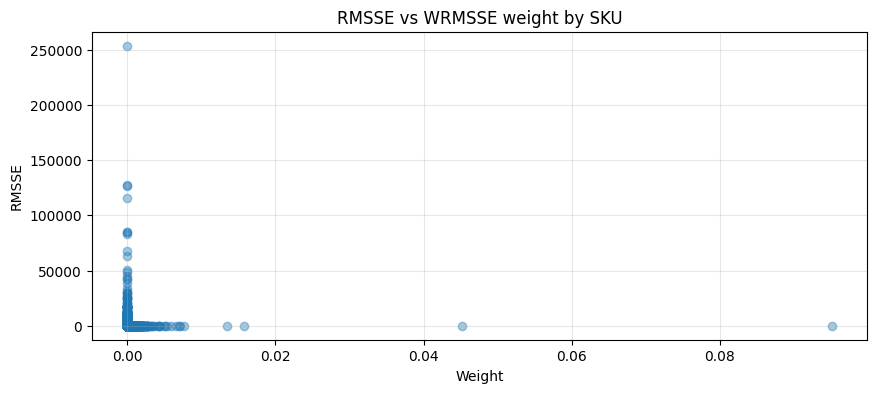

In [24]:
# Xem lỗi ở các SKU có weight cao nhất
top_error = (
    sku_eval.sort_values("weight", ascending=False)
    .head(100)
    .sort_values("rmsse", ascending=False)
)

display(top_error.head(30))

plt.figure(figsize=(10, 4))
plt.scatter(sku_eval["weight"], sku_eval["rmsse"], alpha=0.4)
plt.title("RMSSE vs WRMSSE weight by SKU")
plt.xlabel("Weight")
plt.ylabel("RMSSE")
plt.grid(True, alpha=0.3)
plt.show()

## 12. Gợi ý EDA nâng cao trước khi model

Các câu hỏi nên kiểm tra tiếp:
1. Top 100/500 SKU profit cao có pattern riêng không?
2. Có SKU nào bán đều theo chu kỳ 7 ngày/28 ngày không?
3. Có tháng nào thấp/cao bất thường không?
4. SKU nào mới xuất hiện gần cuối train?
5. SKU nào đã lâu không bán nhưng vẫn profit cao?
6. Forecast chủ nhật có nên gần 0 không?
7. Baseline có overpredict SKU sparse không?

Sau EDA, nên làm model:
- Rule-based cho SKU cực thưa.
- LightGBM/CatBoost cho SKU profit cao hoặc bán thường xuyên.
- Blend baseline + ML.

## 13. Tạo submission baseline

Phần này chỉ chạy nếu có `sample_submission.csv`.

Format cần:

```text
id,F1,F2,...,F28
SKU-00001_validation,...
SKU-00001_evaluation,...
```

- `validation`: 2025-09-06 → 2025-10-03.
- `evaluation`: 2025-10-04 → 2025-10-31.

In [26]:
def make_submission_from_long_pred(sample_sub, pred_long):
    """
    pred_long cần có:
    ItemCode, Date, pred

    sample_sub có:
    id, F1..F28
    """
    sub = sample_sub.copy()
    fcols = [c for c in sub.columns if c.startswith("F")]

    # Parse id
    sub["window"] = sub["id"].str.extract(r"_(validation|evaluation)$")[0]
    sub["ItemCode"] = sub["id"].str.replace(r"_(validation|evaluation)$", "", regex=True)

    date_map = {
        "validation": pd.date_range("2025-09-06", periods=28, freq="D"),
        "evaluation": pd.date_range("2025-10-04", periods=28, freq="D")
    }

    pred_lookup = pred_long.set_index(["ItemCode", "Date"])["pred"]

    for idx, row in sub.iterrows():
        dates = date_map[row["window"]]
        item = row["ItemCode"]
        vals = []
        for d in dates:
            vals.append(float(pred_lookup.get((item, d), 0.0)))
        sub.loc[idx, fcols] = vals

    # Chỉ giữ đúng cột gốc
    sub = sub[sample_sub.columns]

    # Safety checks
    assert sub["id"].is_unique, "Duplicate id detected!"
    assert set(sub["id"]) == set(sample_sub["id"]), "Submission id set mismatch!"
    assert sub.shape == sample_sub.shape, "Submission shape mismatch!"
    assert (sub[fcols].to_numpy() >= 0).all(), "Negative predictions detected!"

    return sub


if SAMPLE_PATH.exists():
    sample_sub = pd.read_csv(SAMPLE_PATH)
    display(sample_sub.head())
    print("sample shape:", sample_sub.shape)

    forecast_dates_56 = pd.date_range("2025-09-06", periods=56, freq="D")
    final_pred_long, final_base_table, final_weekday_factor = build_baseline_forecast(
        df,
        forecast_dates_56,
        sku_list
    )

    submission = make_submission_from_long_pred(sample_sub, final_pred_long)
    display(submission.head())
    display(submission.tail())

    out_path = "submission_baseline_eda.csv"
    submission.to_csv(out_path, index=False)
    print("Saved:", out_path)
else:
    print("Không tìm thấy sample_submission.csv nên bỏ qua bước tạo submission.")
    print("Hãy đặt sample_submission.csv cùng thư mục rồi chạy lại cell này.")

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,SKU-00001_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SKU-00002_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SKU-00003_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SKU-00004_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SKU-00005_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


sample shape: (31944, 29)


/var/folders/h4/1myh9v5149vfd754lvvkttpw0000gn/T/ipykernel_7586/887406628.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1447734749515046' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[idx, fcols] = vals
/var/folders/h4/1myh9v5149vfd754lvvkttpw0000gn/T/ipykernel_7586/887406628.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.008113095238095237' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[idx, fcols] = vals
/var/folders/h4/1myh9v5149vfd754lvvkttpw0000gn/T/ipykernel_7586/887406628.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.20403752046187837' has dtype incompatible with int64, please explicitly cast to a compatible d

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,SKU-00001_validation,0.1448,0.0081,0.2040,0.1896,0.1987,0.1997,0.1982,0.1448,0.0081,0.2040,0.1896,0.1987,0.1997,0.1982,0.1448,0.0081,0.2040,0.1896,0.1987,0.1997,0.1982,0.1448,0.0081,0.2040,0.1896,0.1987,0.1997,0.1982
1,SKU-00002_validation,4.8732,0.2731,6.8680,6.3821,6.6891,6.7211,6.6723,4.8732,0.2731,6.8680,6.3821,6.6891,6.7211,6.6723,4.8732,0.2731,6.8680,6.3821,6.6891,6.7211,6.6723,4.8732,0.2731,6.8680,6.3821,6.6891,6.7211,6.6723
2,SKU-00003_validation,10.2324,0.5734,14.4211,13.4007,14.0454,14.1125,14.0102,10.2324,0.5734,14.4211,13.4007,14.0454,14.1125,14.0102,10.2324,0.5734,14.4211,13.4007,14.0454,14.1125,14.0102,10.2324,0.5734,14.4211,13.4007,14.0454,14.1125,14.0102
3,SKU-00004_validation,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,SKU-00005_validation,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
31939,SKU-16329_evaluation,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
31940,SKU-16330_evaluation,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
31941,SKU-16331_evaluation,0.0001,0.0000,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0000,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0000,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0000,0.0001,0.0001,0.0001,0.0001,0.0001
31942,SKU-16332_evaluation,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
31943,SKU-16333_evaluation,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Saved: submission_baseline_eda.csv


## 14. Checklist trước khi submit

Trước khi nộp Kaggle:
- [ ] File có đúng số dòng bằng `sample_submission.csv`.
- [ ] Không thiếu `id`.
- [ ] Không duplicate `id`.
- [ ] Các cột `F1` → `F28` đều là số.
- [ ] Không có giá trị âm.
- [ ] Không có NaN.
- [ ] Không tự round nếu không cần, metric chấm float trực tiếp.
- [ ] Đã chọn đúng file submission.

In [27]:
# Optional: kiểm tra submission nếu đã tạo
if "submission" in globals():
    fcols = [c for c in submission.columns if c.startswith("F")]
    print("Shape:", submission.shape)
    print("Duplicate id:", submission["id"].duplicated().sum())
    print("NaN count:", submission[fcols].isna().sum().sum())
    print("Negative count:", (submission[fcols] < 0).sum().sum())
    display(submission[fcols].describe().T.head())

Shape: (31944, 29)
Duplicate id: 0
NaN count: 0
Negative count: 0


,count,mean,std,min,25%,50%,75%,max
F1,"31,944.0000",0.0724,0.9259,0.0000,0.0000,0.0000,0.0052,82.0987
F2,"31,944.0000",0.0041,0.0519,0.0000,0.0000,0.0000,0.0003,4.6008
F3,"31,944.0000",0.1021,1.3049,0.0000,0.0000,0.0000,0.0073,115.7064
F4,"31,944.0000",0.0948,1.2126,0.0000,0.0000,0.0000,0.0067,107.5196
F5,"31,944.0000",0.0994,1.2709,0.0000,0.0000,0.0000,0.0071,112.6917
